Initiating Volume Ratio Factor Diagnostic...
Processing Snapshot: 2026-03-31

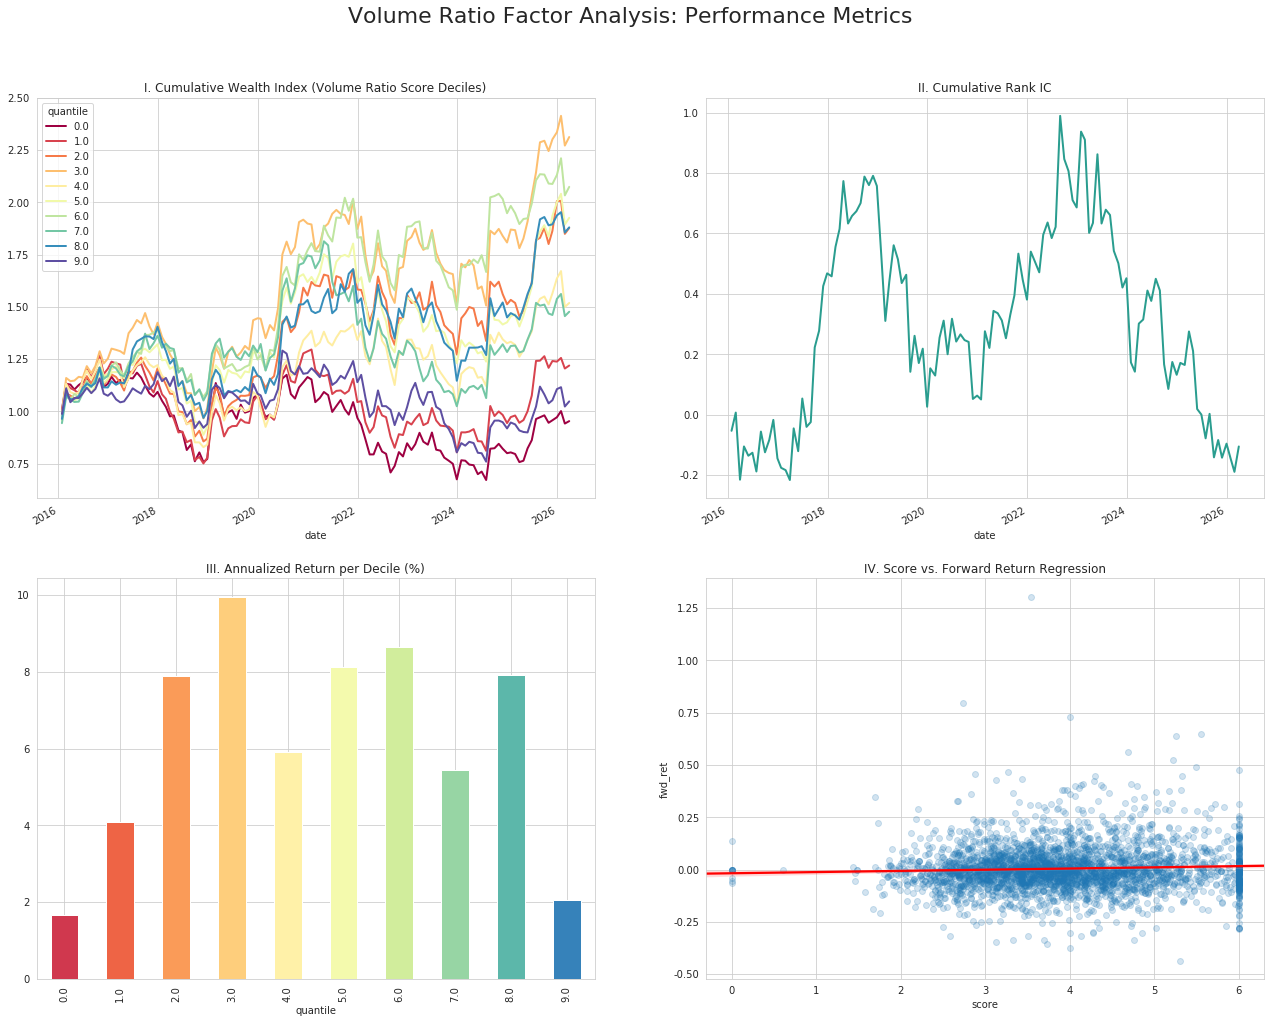

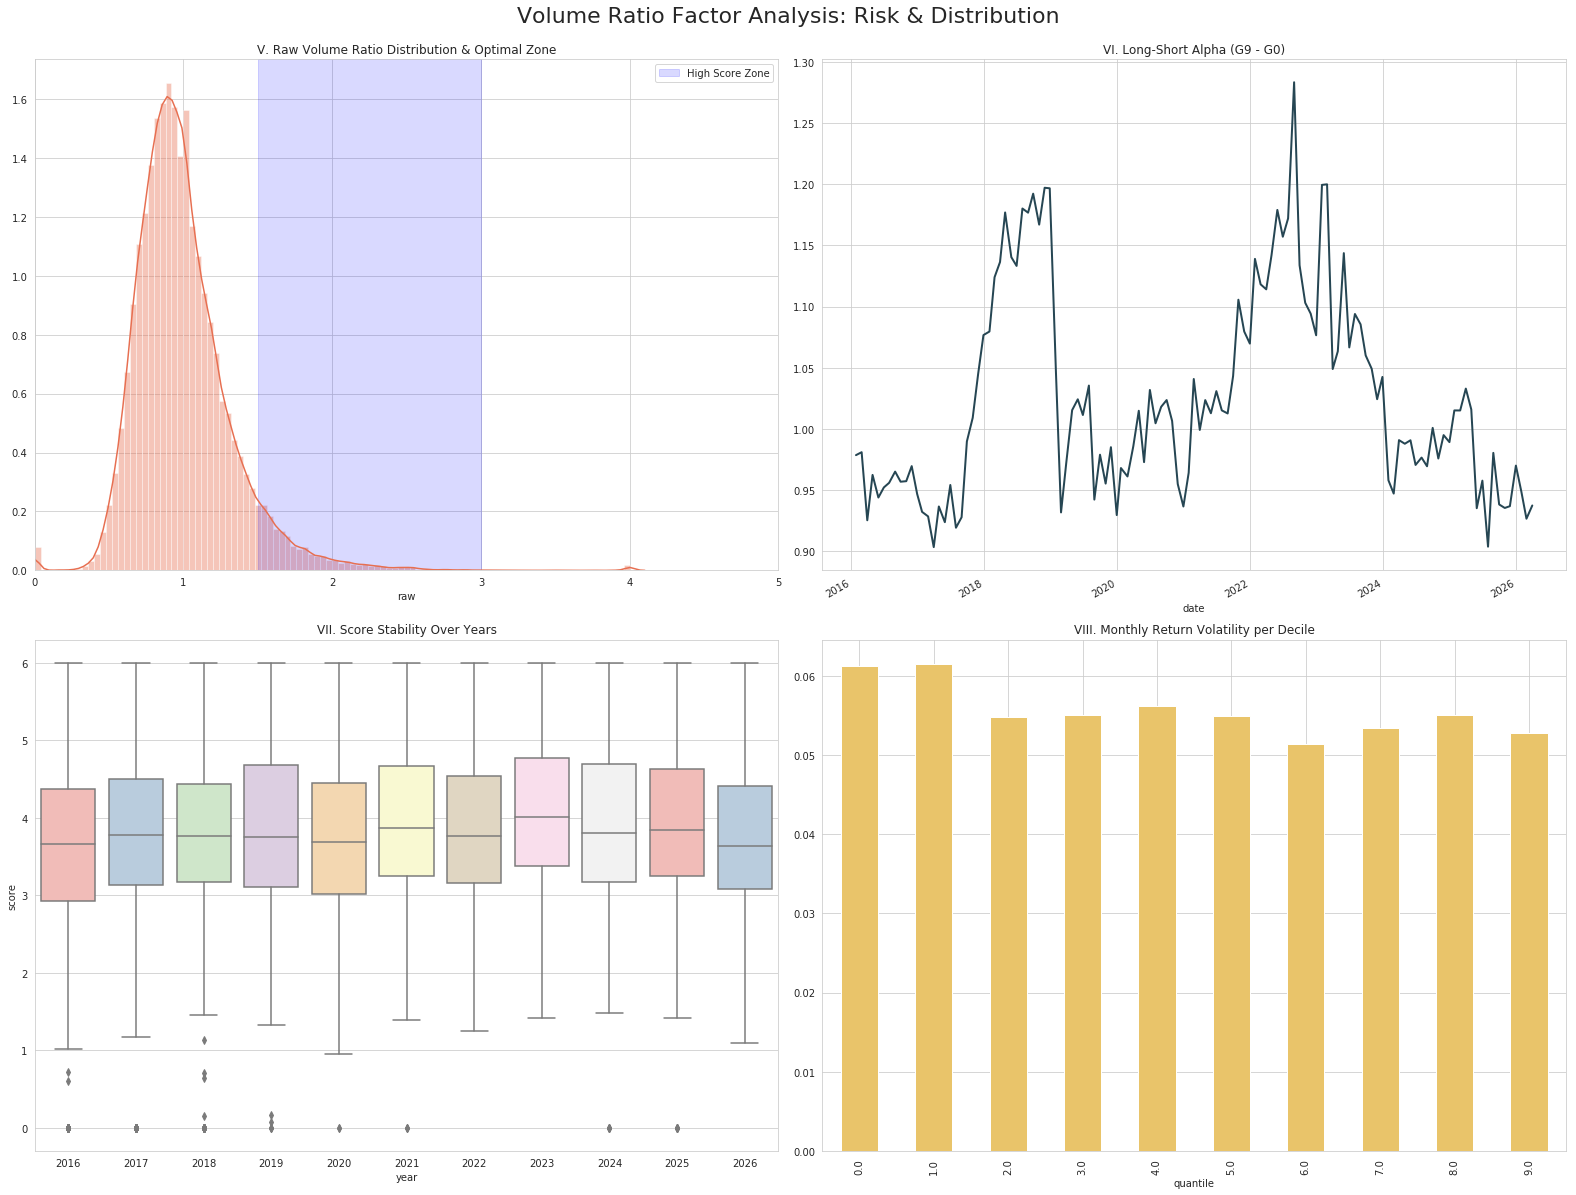


Average IC: -0.0009 | ICIR: -0.0073


In [ ]:
'''
This factor is constructed using the "Volume Ratio" (Relative Volume) logic, 
measuring the intensity of trading activity relative to its recent historical baseline.

The core objective is to identify stocks undergoing "Significant Volume Breakouts." 
By utilizing the calculate_range_score function, we aim to reward stocks with 
moderately expanding volume (indicating strong institutional participation) 
while penalizing those with stagnant volume or extreme "Spike Volume" 
that may suggest a near-term liquidity peak or speculative exhaustion.

This report evaluates the factor's predictive power over the 000300.XSHG universe, 
determining if "Volume-Price Synergy" leads to reliable forward returns.

Due to the high turnover rate of this factor, its excess return is sensitive to transaction costs. 
Subsequent research will focus on the smoothing processing of the Long-term Volume Ratio 
in an effort to reduce signal noise.
'''

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from jqdata import *
import warnings

# 1. Environment Configuration
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

# 2. Core Scoring Logic
def calculate_range_score(value, optimal_range, max_score, reverse=False):
    low, high = optimal_range
    if reverse:
        if value <= low: return max_score
        elif value >= high: return max_score * 0.1
        else: return max_score * (1 - (value - low) / (high - low))
    else:
        if low <= value <= high: return max_score
        elif value < low:
            return max_score * (value / low) if low > 0 else max_score * 0.3
        else:
            # Penalize for excessive volume ratio (Potential climax)
            return max_score * (high / value) if value > 0 else max_score * 0.3

# 3. Parameters and Backtest Engine
start_date, end_date = "2016-01-01", "2026-04-01"
all_days = get_trade_days(start_date, end_date)
ts_series = pd.to_datetime(pd.Series(all_days))
rebal_dates = ts_series.groupby([ts_series.dt.year, ts_series.dt.month]).last()
date_list = [d.strftime('%Y-%m-%d') for d in rebal_dates]

# Simulation Configuration
short_p, long_p = 5, 20
opt_range = (1.5, 3.0)  # Moderate volume surge is usually optimal
weight = 6

dataset = []
print("Initiating Volume Ratio Factor Diagnostic...")

for i in range(len(date_list) - 1):
    t0, t1 = date_list[i], date_list[i+1]
    universe = get_index_stocks('000300.XSHG', date=t0)
    print("\rProcessing Snapshot: {}".format(t0), end="")
    
    # Get volume data (need enough days for long MA)
    v_data = get_price(universe, end_date=t0, count=long_p, fields='volume', panel=False)
    
    res = []
    for s in universe:
        s_v = v_data[v_data['code'] == s]['volume']
        if len(s_v) < long_p: continue
        
        # Calculate Volume Ratio
        vol_ma_short = s_v.iloc[-short_p:].mean()
        vol_ma_long = s_v.mean()
        v_ratio = vol_ma_short / vol_ma_long if vol_ma_long != 0 else 1
        
        score = calculate_range_score(v_ratio, opt_range, weight)
        res.append({'code': s, 'raw': v_ratio, 'score': score})
    
    if not res: continue
    
    df = pd.DataFrame(res)
    p0 = get_price(list(df['code']), end_date=t0, count=1, fields='close', panel=False).set_index('code')['close']
    p1 = get_price(list(df['code']), end_date=t1, count=1, fields='close', panel=False).set_index('code')['close']
    
    df['fwd_ret'] = df['code'].map((p1 / p0) - 1)
    df['date'] = pd.to_datetime(t0)
    dataset.append(df)

master_df = pd.concat(dataset, ignore_index=True).dropna()
master_df['year'] = master_df['date'].dt.year
master_df['quantile'] = master_df.groupby('date')['score'].transform(
    lambda x: pd.qcut(x.rank(method='first'), 10, labels=False)
)

# 4. Performance & Risk Attribution (9-Plot System)
ic_ts = master_df.groupby('date').apply(lambda g: g['score'].corr(g['fwd_ret']))
q_ret = master_df.groupby(['date', 'quantile'])['fwd_ret'].mean().unstack()

# Plot Set 1
fig1, axes1 = plt.subplots(2, 2, figsize=(22, 18))
plt.suptitle('Volume Ratio Factor Analysis: Performance Metrics', fontsize=22, y=0.95)

(1 + q_ret).cumprod().plot(ax=axes1[0, 0], colormap='Spectral', lw=2)
axes1[0, 0].set_title("I. Cumulative Wealth Index (Volume Ratio Score Deciles)")

ic_ts.cumsum().plot(ax=axes1[0, 1], color='#2a9d8f', lw=2)
axes1[0, 1].set_title("II. Cumulative Rank IC")

(q_ret.mean() * 12 * 100).plot(kind='bar', color=sns.color_palette("Spectral", 10), ax=axes1[1, 0])
axes1[1, 0].set_title("III. Annualized Return per Decile (%)")

sns.regplot(x='score', y='fwd_ret', data=master_df.sample(min(len(master_df), 3000)), 
            ax=axes1[1, 1], scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
axes1[1, 1].set_title("IV. Score vs. Forward Return Regression")

# Plot Set 2
fig2, axes2 = plt.subplots(2, 2, figsize=(22, 18))
plt.suptitle('Volume Ratio Factor Analysis: Risk & Distribution', fontsize=22, y=0.95)

# V. Raw Value Distribution (Compatibility fix)
sns.distplot(master_df['raw'], bins=100, color='#e76f51', ax=axes2[0, 0])
axes2[0, 0].axvspan(opt_range[0], opt_range[1], color='blue', alpha=0.15, label='High Score Zone')
axes2[0, 0].set_title("V. Raw Volume Ratio Distribution & Optimal Zone")
axes2[0, 0].set_xlim(0, 5) # Cut off extreme outliers for visibility
axes2[0, 0].legend()

# VI. L/S Alpha
(1 + (q_ret[9] - q_ret[0])).cumprod().plot(ax=axes2[0, 1], color='#264653', lw=2)
axes2[0, 1].set_title("VI. Long-Short Alpha (G9 - G0)")

# VII. Score Stability
sns.boxplot(x='year', y='score', data=master_df, palette='Pastel1', ax=axes2[1, 0])
axes2[1, 0].set_title("VII. Score Stability Over Years")

# VIII. Risk Attribution
q_ret.std().plot(kind='bar', color='#e9c46a', ax=axes2[1, 1])
axes2[1, 1].set_title("VIII. Monthly Return Volatility per Decile")

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

print("\nAverage IC: {:.4f} | ICIR: {:.4f}".format(ic_ts.mean(), ic_ts.mean()/ic_ts.std()))